In [2]:
using Random, GMRF

include("src/dataGen.jl");
include("src/cavi.jl");
include("src/mcmc.jl");
include("src/plotting.jl");

Taille de la grille (à ne pas modifier)

In [94]:
M₁ = 20;
M₂ = 20;
M = M₁ * M₂;

- Génération de la grille cible
- Création des données artificielles

In [95]:
Random.seed!(300);
Fmu = iGMRF(M₁, M₂, 1, 10);
Fphi = iGMRF(M₁, M₂, 1, 100);
gridTarget = generateTargetGrid(Fmu, Fphi);
gridTarget[:, :, 1] = gridTarget[:, :, 1] .+ 10.0;
gridTarget[:, :, 2] = gridTarget[:, :, 2] .+ 1.0;
gridTarget[:, :, 3] = gridTarget[:, :, 3] .+ .3;
nobs = 100;
data = generateData(gridTarget, nobs);

# CAVI

In [125]:
nEpoch = 3;
epochSize = 10;

initialValues = Dict(
    :μ => zeros(M),
    :ϕ => zeros(M),
    :ξ => 0.0,
);

spatialScheme = Dict(
    :M => M,
    :Fmu => Fmu,
    :Fphi => Fphi,
    :data => data,
);

In [126]:
include("src/cavi.jl");

res = runCAVI(nEpoch, epochSize, initialValues, spatialScheme);

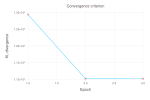

In [127]:
plotConvergenceCriterion(res.MCKL)

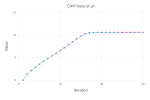

In [128]:
plotTraceCAVI(res.traces[:muMean][1, :], "μ1")

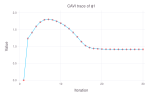

In [129]:
plotTraceCAVI(res.traces[:phiMean][1, :], "ϕ1")

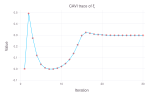

In [130]:
plotTraceCAVI(res.traces[:xiMean][:], "ξ")

# MCMC

In [115]:
datastructure = Dict(
    :Y => data,
    :Fmu => Fmu,
    :Fphi => Fphi,
);

niter = 10000;

initialvalues = Dict(
    :μ => zeros(M),
    :ϕ => zeros(M),
    :ξ => .2,
);

stepsize = Dict(
    :μ => .7,
    :ϕ => .23,
    :ξ => .02,
);

In [116]:
include("src/mcmc.jl")

chain = mcmc(datastructure, niter, initialvalues, stepsize);

Progress: 100%|█████████████████████████████████████████| Time: 0:01:10


In [117]:
changerate(chain)

             Change Rate
          μ1       0.276
          μ2       0.236
          μ3       0.227
          μ4       0.228
          μ5       0.249
          μ6       0.246
          μ7       0.251
          μ8       0.254
          μ9       0.248
         μ10       0.254
         μ11       0.235
         μ12       0.249
         μ13       0.245
         μ14       0.239
         μ15       0.251
         μ16       0.255
         μ17       0.241
         μ18       0.252
         μ19       0.254
         μ20       0.294
         μ21       0.222
         μ22       0.216
         μ23       0.216
         μ24       0.215
         μ25       0.214
         μ26       0.223
         μ27       0.233
         μ28       0.233
         μ29       0.229
         μ30       0.230
         μ31       0.216
         μ32       0.228
         μ33       0.223
         μ34       0.233
         μ35       0.225
         μ36       0.229
         μ37       0.227
         μ38       0.226
         μ39       0.239


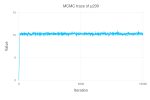

In [118]:
plotTraceMCMC(chain, "μ200")

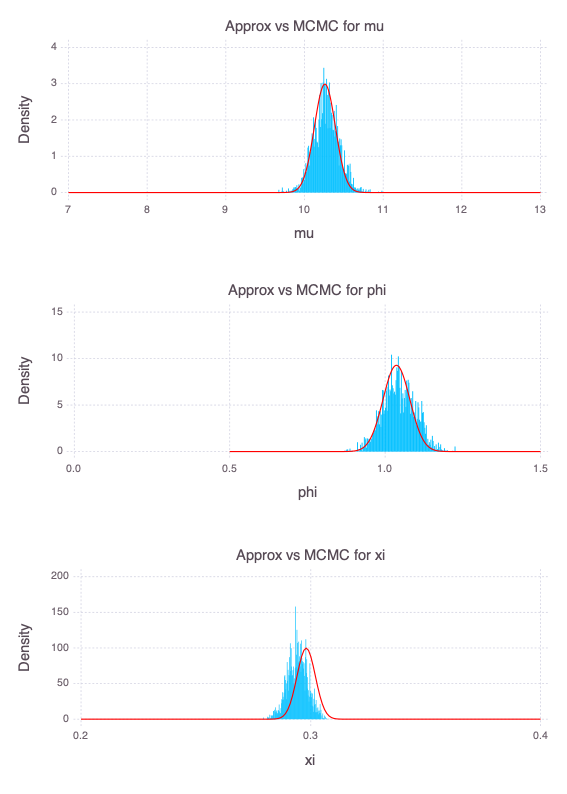

In [131]:
include("src/plotting.jl");

plotCAVIvsMCMC(200, caviRes=res, mcmcChain=chain, warmingSize=1000)